In [1]:
import torch
import sys
import torch
import geopandas as gpd
import pandas as pd
from matplotlib.patches import Patch


sys.path.append('./satclip/satclip')

from matplotlib import pyplot as plt
from dotenv import load_dotenv
import os

load_dotenv()
import random
import numpy as np



try:
    RANDOM_SEED = int(os.environ["RANDOM_SEED"])
except:
    RANDOM_SEED = 15


random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)


torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

TRAIN_FOLDS = os.environ.get("TRAIN_FOLDS", [0,1,2])
VALID_FOLDS = os.environ.get("VALID_FOLDS", [3])
TEST_FOLDS = os.environ.get("TEST_FOLDS", [4])


AEZ_ROOT = os.getenv("AEZ_ROOT", "data/aez")
GPKGS_ROOT = os.getenv("GPKGS_ROOT", "data/gpkgs")

parent_rng = np.random.default_rng(seed=RANDOM_SEED)

gdf = gpd.read_file(f"../../{GPKGS_ROOT}/bda_2024_patches_2024_classified.gpkg", driver="gpkg")

aez_number_to_class_label = {}
with open(f"../../{AEZ_ROOT}/AEZ_57classes.clr", "r") as infile:
    for line in infile:
        parts = line.strip().split()
        aez_number_to_class_label[int(parts[0])] = " ".join(parts[5:])

aez_number_to_class_label[0] = "Unclassified"

def get_new_random_seed():
    return parent_rng.integers(0,2**32)

/home/nathan/Desktop/BDA_integration/.venv/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(


In [2]:
gdf = gdf[gdf["tile"] != -1]
len(pd.unique(gdf["tile"]))

30

In [3]:
#TODO check the amount that would be dropped with AEZ class
#TODO 

In [4]:
print(len(gdf))
value_counts = gdf["tile"].value_counts()
if -1 in value_counts.index:
        value_counts = value_counts.drop(index=[-1])
mean_count = value_counts.mean()
threshold = 0#0.05 * mean_count
keep_tiles = list(value_counts[value_counts > threshold].index.values)
gdf = gdf[gdf["tile"].isin(keep_tiles)]
print(len(gdf))

495307
495307


In [5]:
child_rng = np.random.default_rng(get_new_random_seed())
test_tiles = child_rng.choice(keep_tiles, int(len(keep_tiles)/6))
test_tiles

array([27, 35, 16,  9, 12])

<Axes: >

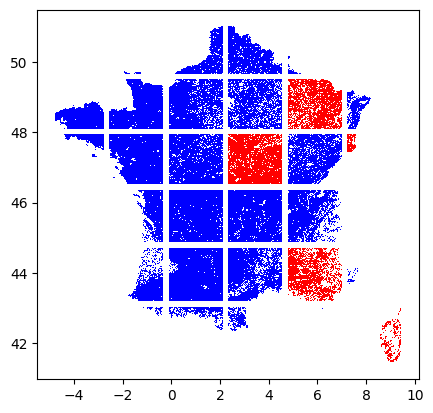

In [6]:
colors = ["red" if i in test_tiles else "blue" for i in gdf["tile"]]

gdf.plot(color=colors)

In [7]:
gdf.columns

Index(['hedgerows', 'aez_class', 'thz_class', 'mst_class', 'fold',
       'plot_color', 'quadrant', 'sixteenth', 'tile', 'geometry'],
      dtype='str')

In [8]:
gdf["fold"]

3         2
4         2
5         2
6        -1
7         3
         ..
603080    0
603081    0
603082    0
603083    0
603084    0
Name: fold, Length: 495307, dtype: int64

In [9]:
near_gdf = gdf[~gdf["tile"].isin(test_tiles)]
far_gdf = gdf[gdf["tile"].isin(test_tiles)]


def sample_gdf(gdf, folds, split, n_per_fold=500):
    dfs = []

    value_pcts = gdf["tile"].value_counts().apply(lambda x: x / len(gdf))
    for f in folds:
        inner_gdfs = []
        for t in pd.unique(gdf["tile"]):
            sub_gdf = gdf[(gdf["tile"] == t) & (gdf["fold"] == f)]
            if len(sub_gdf) == 0:
                continue
            pct = float(value_pcts.loc[t]) 
            child_rng = np.random.default_rng(get_new_random_seed())
            n_t = n_per_fold * pct

            inds = child_rng.choice([i for i in range(len(sub_gdf))], int(round(n_t)))
            sub_gdf_sampled = sub_gdf.iloc[inds]
            inner_gdfs.append(sub_gdf_sampled)
        
        print(len(inner_gdfs))

        full_inner_gdf = pd.concat(inner_gdfs, axis=0)
        dfs.append(full_inner_gdf)
    full_gdf = pd.concat(dfs, axis=0)
    full_gdf["split"] = [split] * len(full_gdf)
    return full_gdf
train_gdf = sample_gdf(near_gdf, TRAIN_FOLDS, "train")
valid_gdf = sample_gdf(near_gdf, VALID_FOLDS, "valid")
test_near_gdf = sample_gdf(near_gdf, TEST_FOLDS, "test_near")
test_far_gdf = sample_gdf(far_gdf, TEST_FOLDS, "test_far")

24
24
25
24
25
5


In [10]:
len(train_gdf)

1503

In [11]:
aez_class_subgroups = {
    "Sub-tropics, cool": [
        "Sub-tropics, cool; humid, no soil/terrain limitations",
        "Sub-tropics, cool; sub-humid, with soil/terrain limitations",
        "Sub-tropics, cool; sub-humid, no soil/terrain limitations",
    ],
    "Sub-tropics, mod.cool": [
        "Sub-tropics, mod. cool; humid, no soil/terrain limitations",
        "Sub-tropics, mod. cool; sub-humid, no soil/terrain limitations",
        "Sub-tropics, mod. cool; humid, with soil/terrain limitations",
        "Sub-tropics, mod. cool; sub-humid, with soil/terrain limitations"
    ],

    "Temperate, cool, moist": [
        "Temperate, cool; moist, no soil/terrain limitations",
        "Temperate, cool; moist, with soil/terrain limitations",
    ],

    "Temperate, cool, wet": [
        "Temperate, cool; wet, with soil/terrain limitations",
        "Temperate, cool; wet, no soil/terrain limitations",
    ],

    
    "Temperate, moderate": [
        "Temperate, moderate; moist, with soil/terrain limitations",
        "Temperate, moderate; moist, no soil/terrain limitations"
    ],

    "Terrain-dominated": [
        "Dominantly hydromorphic soils",
        "Dominantly very steep terrain",
        "Dominantly built-up land",
    ],

    "Misc": [
        "Ample irrigated soils",
        "Land with severe soil/terrain limitations",
        "Unclassified"
    ],
    
}

In [12]:
for k in aez_class_subgroups:
    print(k)
    print(len(train_gdf[train_gdf["aez_class"].isin(aez_class_subgroups[k])]))

Sub-tropics, cool
105
Sub-tropics, mod.cool
76
Temperate, cool, moist
437
Temperate, cool, wet
613
Temperate, moderate
0
Terrain-dominated
47
Misc
167


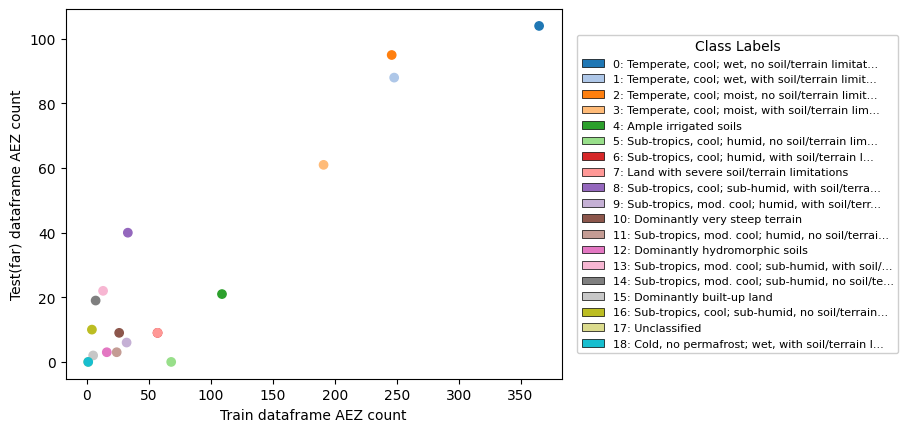

In [13]:
value_counts = train_gdf["aez_class"].value_counts().sort_values(ascending=False)
test_far_value_counts = test_far_gdf["aez_class"].value_counts().sort_index()
test_far_value_counts = test_far_value_counts.reindex(value_counts.index, fill_value=0)
colors = plt.cm.tab20(np.arange(len(value_counts)))
class_to_color = {class_name: colors[i] for i, class_name in enumerate(value_counts.index)}

plt.xlabel("Train dataframe AEZ count")
plt.ylabel("Test(far) dataframe AEZ count")
plt.scatter(x=value_counts, y=test_far_value_counts, c=colors)

legend_labels = [f"{i}: {str(label)[:45]}{'...' if len(str(label)) > 45 else ''}" 
                for i, label in enumerate(value_counts.index)]
legend_handles = [Patch(facecolor=colors[i], edgecolor='black', linewidth=0.5) 
                    for i in range(len(value_counts))]

plt.legend(legend_handles, legend_labels,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
        framealpha=0.95,
        title='Class Labels',
        title_fontsize=10,
        ncol=1)
plt.show()


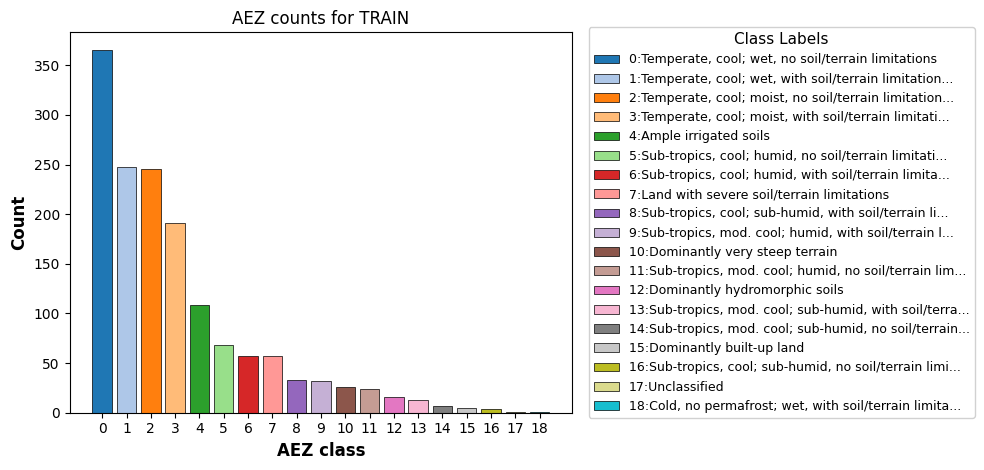

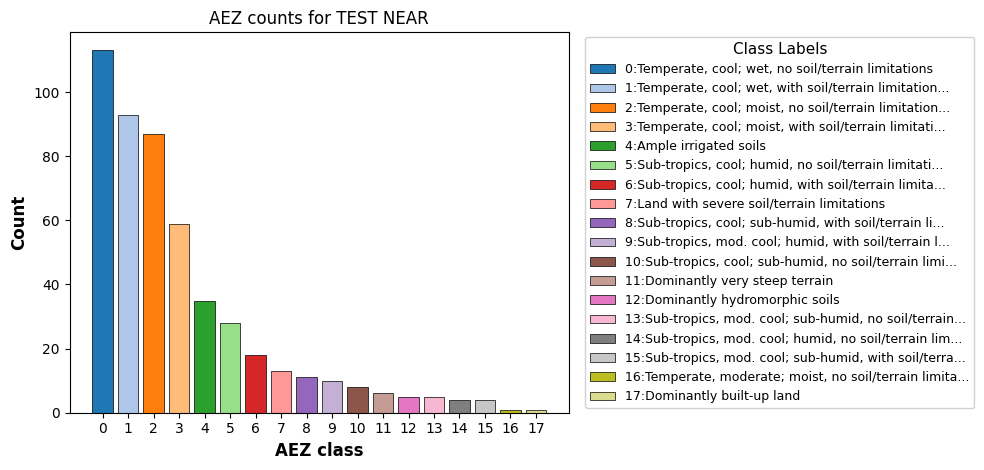

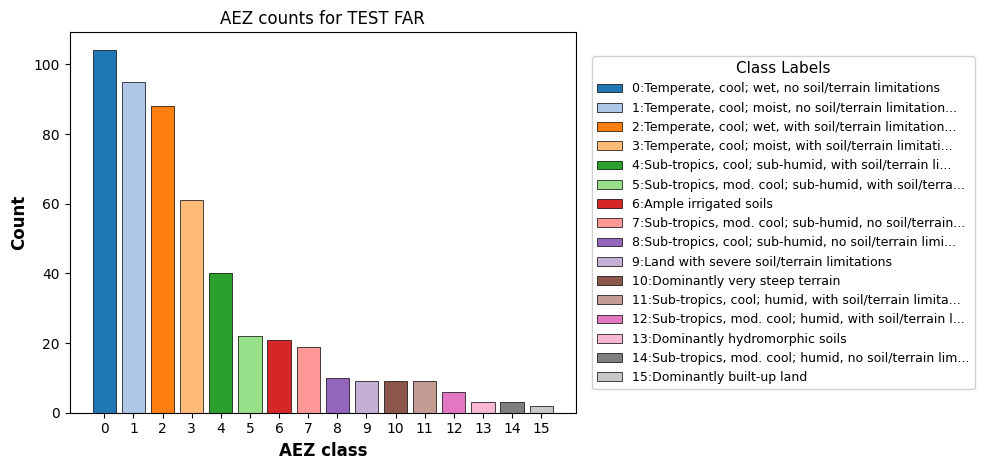

In [14]:
def plot_aez_counts(gdf,title="AEZ Counts"):
        value_counts = gdf["aez_class"].value_counts().sort_values(ascending=False)
        fig = plt.figure()
        fig.set_figwidth(10)
        bars = plt.bar(range(len(value_counts)), value_counts, color=colors, edgecolor='black', linewidth=0.5)

        plt.xlabel('AEZ class', fontsize=12, fontweight='bold')
        plt.ylabel('Count', fontsize=12, fontweight='bold')
        plt.xticks(range(len(value_counts)))
        plt.title(title)
        legend_labels = [f"{i}:{label[:50]}{'...' if len(label) > 50 else ''}" 
                        for i, label in enumerate(value_counts.index)]

        plt.legend(bars, legend_labels, 
                loc='center left', 
                bbox_to_anchor=(1.02, 0.5),
                fontsize=9,
                framealpha=0.9,
                title='Class Labels',
                title_fontsize=11)

        plt.tight_layout()
        plt.show()

plot_aez_counts(train_gdf, title="AEZ counts for TRAIN")
plot_aez_counts(test_near_gdf, title="AEZ counts for TEST NEAR")
plot_aez_counts(test_far_gdf, title="AEZ counts for TEST FAR")

In [15]:
missing_classes = near_gdf[~near_gdf["aez_class"].isin(pd.unique(far_gdf["aez_class"]))]
len(missing_classes) / len(near_gdf)

2.434333844543441e-05

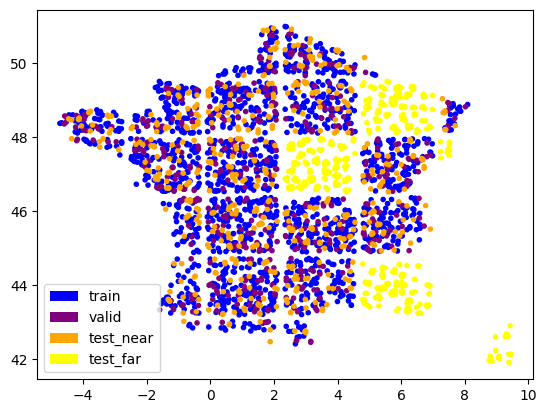

In [16]:
dataset = pd.concat([train_gdf, valid_gdf, test_near_gdf, test_far_gdf])


xs = []
ys = []
colors = []

split_to_col = {
    "train": "blue",
    "valid": "purple",
    "test_near": "orange",
    "test_far": "yellow"
}

for i in range(len(dataset)):
    row = dataset.iloc[i]
    x,y = row.geometry.centroid.xy
    color = split_to_col[row["split"]]
    xs.append(x)
    ys.append(y)
    colors.append(color)

plt.scatter(x=xs, y=ys, c=colors, marker=".")
legend_elements = [Patch(facecolor=color, label=label) 
                   for label, color in split_to_col.items()]
plt.legend(handles=legend_elements)
plt.show()

In [17]:
other_gdf = gpd.read_file(f"../../{GPKGS_ROOT}/hedgementation_dataset_1.1.gpkg")
dataset = dataset.set_index(pd.RangeIndex(0,len(dataset)))


In [18]:
dataset.index

RangeIndex(start=0, stop=3006, step=1)

In [19]:
for col in dataset.columns:
    print(col)
    print(dataset[col].equals(other_gdf[col]))

hedgerows
True
aez_class
True
thz_class
True
mst_class
True
fold
True
plot_color
True
quadrant
True
sixteenth
True
tile
True
geometry
True
split
True


In [20]:
pd.testing.assert_frame_equal(
    dataset.reindex(sorted(dataset.columns), axis=1),
    other_gdf.reindex(sorted(other_gdf.columns), axis=1),
    check_dtype=False
)

In [21]:
dataset.to_file("gpkgs/hedgementation_dataset_1.1.gpkg")